In [1]:
library(UpSetR)

In [1]:
OG_gene <- read.csv('/mnt/gandan/huangzhi/brain/02.Process_file/01.Multi_Reference/OrthoFinder/Results_Jul01/Orthogroups/Orthogroups.tsv',sep='\t',row.names = 1)
OG_gene2 <- read.csv('/mnt/gandan/huangzhi/brain/02.Process_file/01.Multi_Reference/OrthoFinder/Results_Jul01/Orthogroups/Orthogroups_UnassignedGenes.tsv',sep='\t',row.names = 1)
OG_gene <- rbind(OG_gene,OG_gene2)

In [5]:
write.table(OG_gene,'Table/TableS1.OG.tsv',sep='\t')

In [2]:
colnames(OG_gene) <- gsub('.pep','',colnames(OG_gene))

In [3]:
orthgroup <- dplyr::bind_rows(lapply(rownames(OG_gene),function(OG){
tmp_combined_df <- dplyr::bind_rows(lapply(c("Marmoset","Mouse", "Bird", "Turtle",'Axolotl','Lungfish','Fish','Lamprey'),function(species){
    if(OG_gene[OG,species]==''){
        return()
    }
    tmp_df <- data.frame(self_gene=strsplit(OG_gene[OG,species],', ')[[1]])
    tmp_df$species <- species
    tmp_df$OG <- OG
    rownames(tmp_df) <- paste0(tmp_df$species,'_',tmp_df$self_gene)
    return(tmp_df)
}))
    return(tmp_combined_df)}
))

In [254]:
write.csv(orthgroup,'/mnt/gandan/huangzhi/brain/02.Process_file/01.Multi_Reference/OrthoFinder/Results_Jul01/MyDirectory/OG_adj_1028.csv',quote=FALSE)

In [4]:
OG_gene_count <- OG_gene
OG_gene_count[OG_gene_count!=''] <- 1 
OG_gene_count[OG_gene_count==''] <- 0 
OG_gene_count <- matrix(as.numeric(unlist(OG_gene_count)),nrow = nrow(OG_gene_count),ncol=ncol(OG_gene_count),dimnames = dimnames(OG_gene_count))
OG_gene_count <- as.data.frame(OG_gene_count)

In [7]:
upset_data <- as.data.frame.array(OG_gene_count)
colnames(upset_data) <- gsub('.pep','',colnames(upset_data))
options(repr.plot.width=6,repr.plot.height=5)
p_upset <- upset(upset_data, 
      sets = c("Marmoset","Mouse", "Bird", "Turtle",'Axolotl','Lungfish','Fish','Lamprey'),
      order.by = c("freq"),
      sets.x.label = "gene count",main.bar.color = "black", number.angles = 0, point.size = 3, line.size = 1, mainbar.y.label = "intersection number",
      #F48740
      text.scale = c(2, 2, 2, 1.3, 2, 2),
      set_size.show = FALSE, nintersects = 40,
      keep.order = T
      )

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the UpSetR package.
  Please report the issue to the authors.”
Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the UpSetR package.
  Please report the issue to the authors.”
Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.
ℹ The deprecated feature was likely used in the UpSetR package.
  Please report the issue to the authors.”


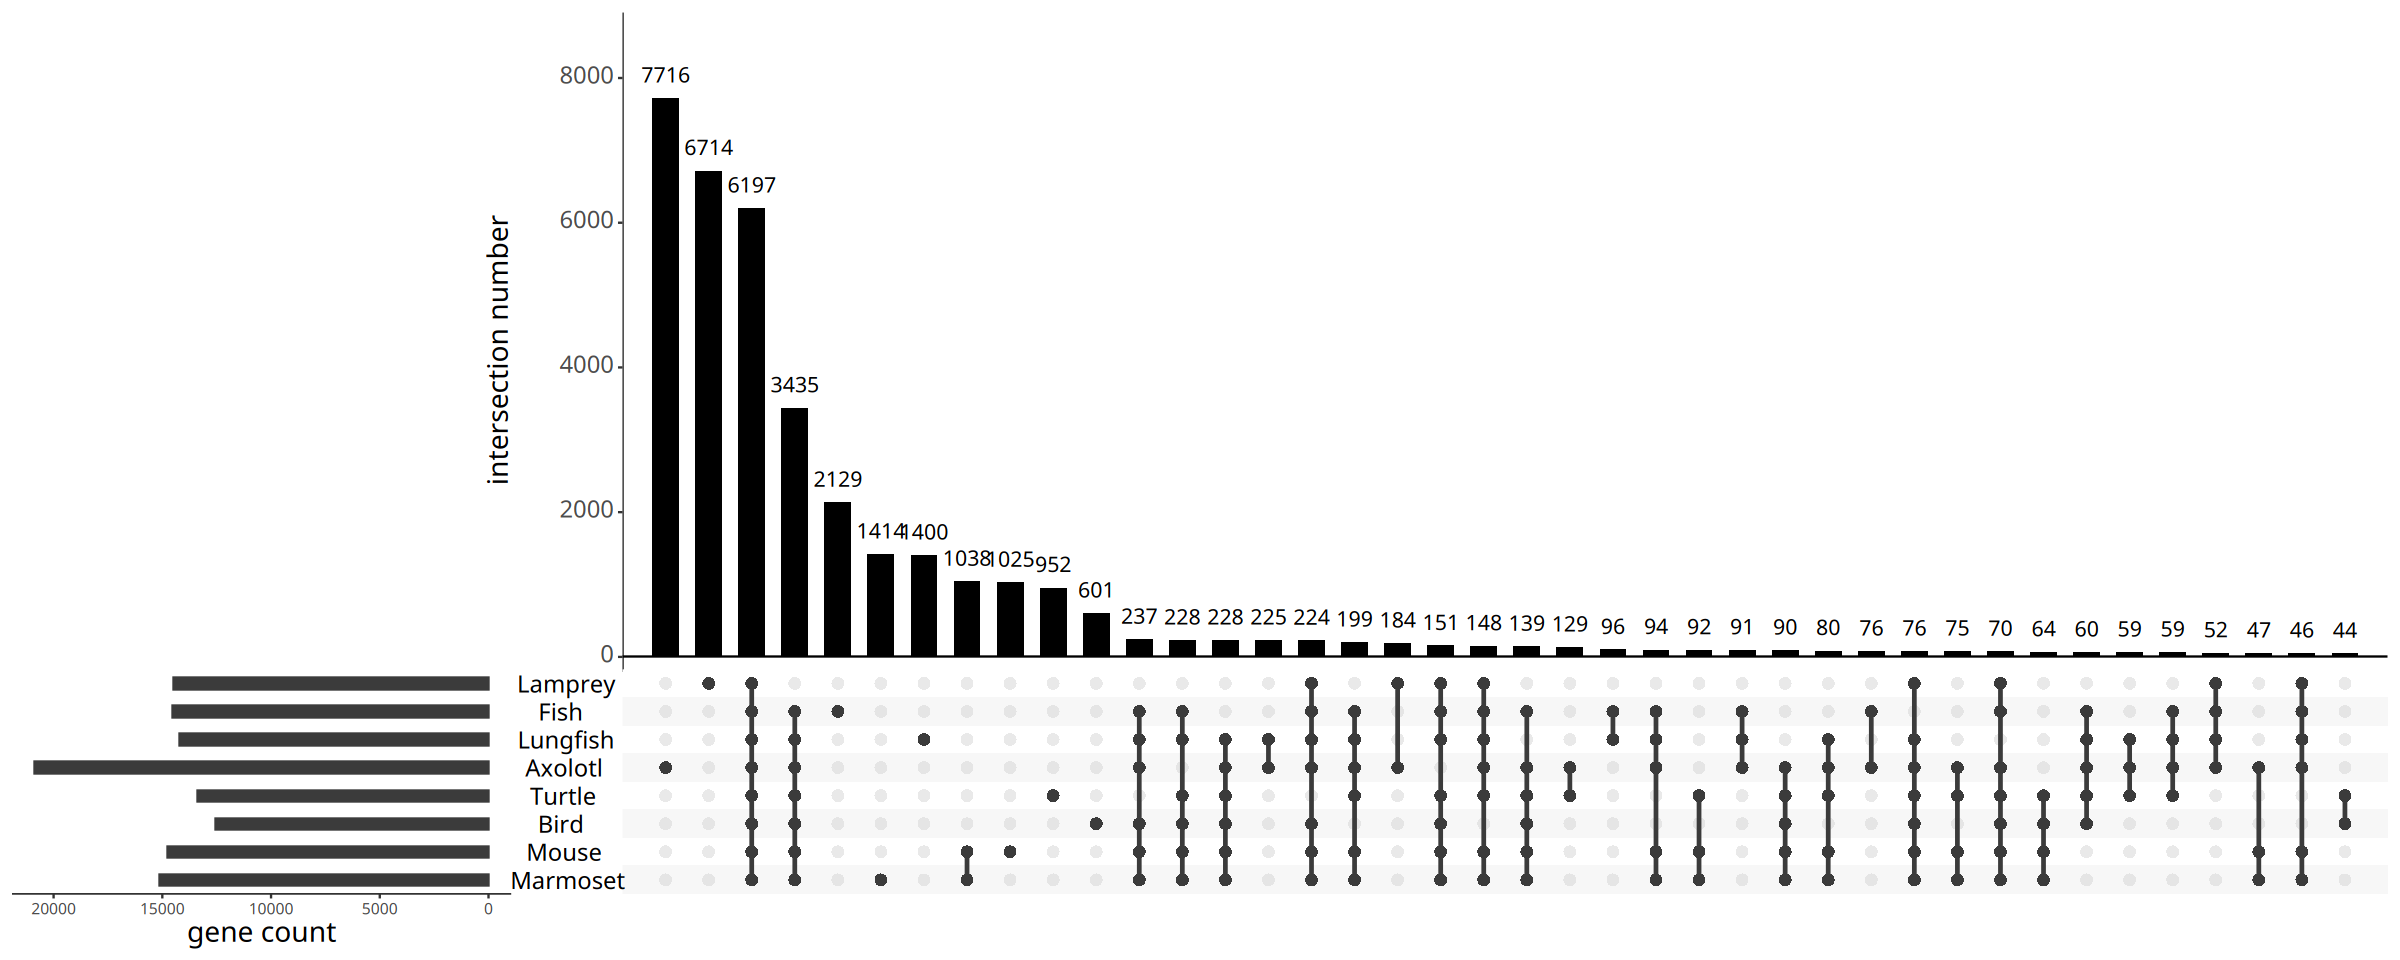

In [8]:
options(repr.plot.height=8,repr.plot.width=20)
p_upset